# Probabilistic Predictive Maintenance and Failure Progression of Railway Systems Using Machine Learning and Probabilistic AI

In [2]:
from pathlib import Path

DATA_PATH = Path(r"D:\metropt+3+dataset\MetroPT3(AirCompressor).csv")

print(DATA_PATH)
print(DATA_PATH.exists())

D:\metropt+3+dataset\MetroPT3(AirCompressor).csv
True


In [3]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully!
Rows    : 1,516,948
Columns : 17


In [4]:
df.head()


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [5]:
print("Columns in the dataset:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

Columns in the dataset:

 1. Unnamed: 0
 2. timestamp
 3. TP2
 4. TP3
 5. H1
 6. DV_pressure
 7. Reservoirs
 8. Oil_temperature
 9. Motor_current
10. COMP
11. DV_eletric
12. Towers
13. MPG
14. LPS
15. Pressure_switch
16. Oil_level
17. Caudal_impulses


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  str    
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1516948 non-

In [7]:
missing_values = df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", missing_values.sum())

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

Total missing values: 0


In [8]:
df.describe()

,Unnamed: 0,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06
mean,7.584735e+06,1.367826e+00,8.984611e+00,7.568155e+00,5.595619e-02,8.985233e+00,6.264418e+01,2.050171e+00,8.369568e-01,1.606106e-01,9.198483e-01,8.326640e-01,3.420025e-03,9.914368e-01,9.041556e-01,9.371066e-01
std,4.379053e+06,3.250930e+00,6.390951e-01,3.333200e+00,3.824015e-01,6.383070e-01,6.516261e+00,2.302053e+00,3.694052e-01,3.671716e-01,2.715280e-01,3.732757e-01,5.838091e-02,9.214078e-02,2.943779e-01,2.427712e-01
min,0.000000e+00,-3.200000e-02,7.300000e-01,-3.600000e-02,-3.200000e-02,7.120000e-01,1.540000e+01,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.792368e+06,-1.400000e-02,8.492000e+00,8.254000e+00,-2.200000e-02,8.494000e+00,5.777500e+01,4.000000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,7.584735e+06,-1.200000e-02,8.960000e+00,8.784000e+00,-2.000000e-02,8.960000e+00,6.270000e+01,4.500000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,1.137710e+07,-1.000000e-02,9.492000e+00,9.374000e+00,-1.800000e-02,9.492000e+00,6.725000e+01,3.807500e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,1.516947e+07,1.067600e+01,1.030200e+01,1.028800e+01,9.844000e+00,1.030000e+01,8.905000e+01,9.295000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
digital_features = [
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses"
]

for col in digital_features:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


COMP
COMP
0.0     247328
1.0    1269620
Name: count, dtype: int64

DV_eletric
DV_eletric
0.0    1273310
1.0     243638
Name: count, dtype: int64

Towers
Towers
0.0     121586
1.0    1395362
Name: count, dtype: int64

MPG
MPG
0.0     253840
1.0    1263108
Name: count, dtype: int64

LPS
LPS
0.0    1511760
1.0       5188
Name: count, dtype: int64

Pressure_switch
Pressure_switch
0.0      12990
1.0    1503958
Name: count, dtype: int64

Oil_level
Oil_level
0.0     145391
1.0    1371557
Name: count, dtype: int64

Caudal_impulses
Caudal_impulses
0.0      95406
1.0    1421542
Name: count, dtype: int64


In [10]:
analog_features = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current"
]

df[analog_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295


In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Timestamp data type:", df["timestamp"].dtype)
print("First timestamp:", df["timestamp"].min())
print("Last timestamp :", df["timestamp"].max())

Timestamp data type: datetime64[us]
First timestamp: 2020-02-01 00:00:00
Last timestamp : 2020-09-01 03:59:50


In [12]:
time_difference = df["timestamp"].diff().dt.total_seconds()

print(time_difference.describe())

count    1.516947e+06
mean     1.214122e+01
std      3.141073e+02
min      8.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.729180e+05
Name: timestamp, dtype: float64


In [13]:
print("Most common sampling intervals:")
print(time_difference.value_counts().head(15))

Most common sampling intervals:
timestamp
10.0     1337521
9.0       128277
12.0       38321
13.0        7988
11.0        4471
21.0          10
19.0           5
22.0           4
20.0           3
17.0           3
23.0           3
14.0           3
308.0          3
307.0          2
502.0          2
Name: count, dtype: int64


In [14]:
print(
    "Median sampling interval:",
    time_difference.median(),
    "seconds"
)

Median sampling interval: 10.0 seconds


In [15]:
failure_periods = [
    {
        "failure_id": 1,
        "start": "2020-04-18 00:00:00",
        "end": "2020-04-18 23:59:00"
    },
    {
        "failure_id": 2,
        "start": "2020-05-29 23:30:00",
        "end": "2020-05-30 06:00:00"
    },
    {
        "failure_id": 3,
        "start": "2020-06-05 10:00:00",
        "end": "2020-06-07 14:30:00"
    },
    {
        "failure_id": 4,
        "start": "2020-07-15 14:30:00",
        "end": "2020-07-15 19:00:00"
    }
]

failure_df = pd.DataFrame(failure_periods)

failure_df["start"] = pd.to_datetime(failure_df["start"])
failure_df["end"] = pd.to_datetime(failure_df["end"])

failure_df

,failure_id,start,end
0,1,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,2020-07-15 14:30:00,2020-07-15 19:00:00


In [16]:
for _, event in failure_df.iterrows():
    mask = (
        (df["timestamp"] >= event["start"]) &
        (df["timestamp"] <= event["end"])
    )
    
    print(
        f"Failure #{event['failure_id']}: "
        f"{mask.sum():,} observations"
    )

Failure #1: 8,657 observations
Failure #2: 2,360 observations
Failure #3: 17,315 observations
Failure #4: 1,622 observations


In [17]:
event = failure_periods[0]

start = pd.Timestamp(event["start"]) - pd.Timedelta(hours=24)
end = pd.Timestamp(event["end"]) + pd.Timedelta(hours=24)

event_df = df[
    (df["timestamp"] >= start) &
    (df["timestamp"] <= end)
].copy()

print("Observations:", len(event_df))
print("Start:", event_df["timestamp"].min())
print("End:", event_df["timestamp"].max())

Observations: 23513
Start: 2020-04-17 00:00:05
End: 2020-04-19 23:58:53


In [18]:
import matplotlib.pyplot as plt

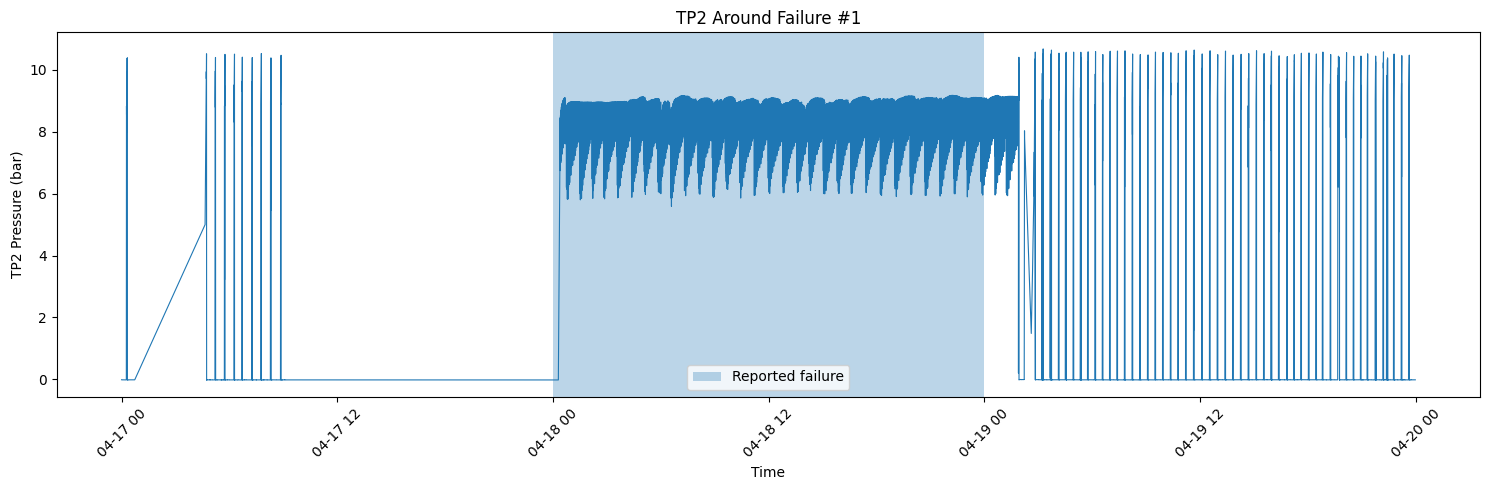

In [19]:
plt.figure(figsize=(15, 5))

plt.plot(
    event_df["timestamp"],
    event_df["TP2"],
    linewidth=0.8
)

plt.axvspan(
    pd.Timestamp(event["start"]),
    pd.Timestamp(event["end"]),
    alpha=0.3,
    label="Reported failure"
)

plt.title("TP2 Around Failure #1")
plt.xlabel("Time")
plt.ylabel("TP2 Pressure (bar)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

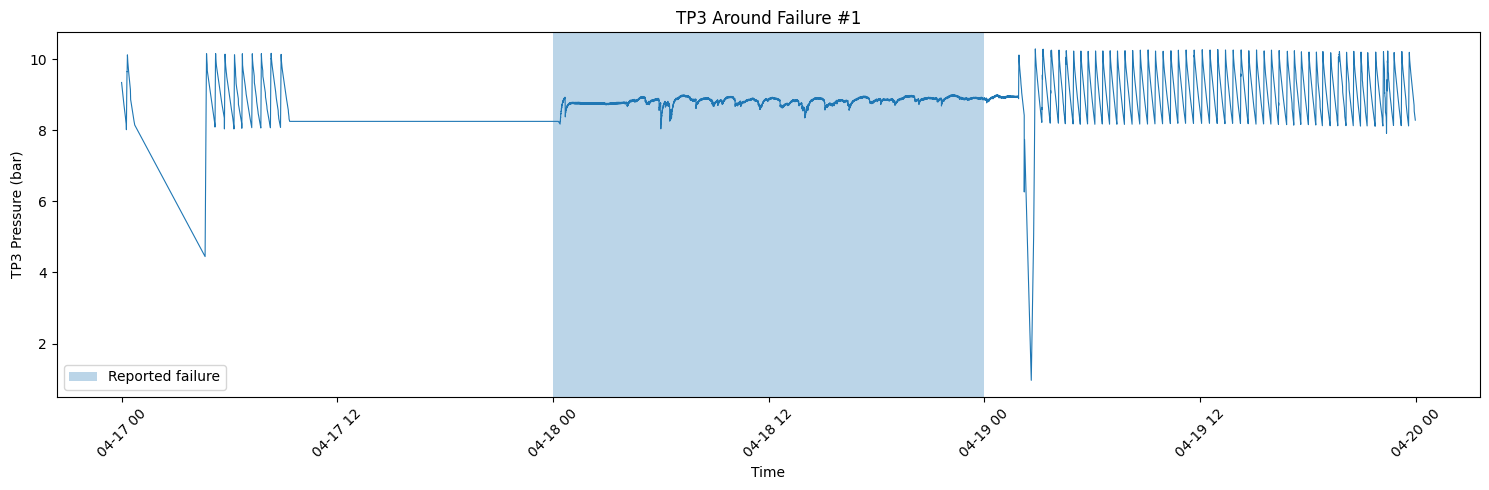

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    event_df["timestamp"],
    event_df["TP3"],
    linewidth=0.8
)

plt.axvspan(
    pd.Timestamp(event["start"]),
    pd.Timestamp(event["end"]),
    alpha=0.3,
    label="Reported failure"
)

plt.title("TP3 Around Failure #1")
plt.xlabel("Time")
plt.ylabel("TP3 Pressure (bar)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

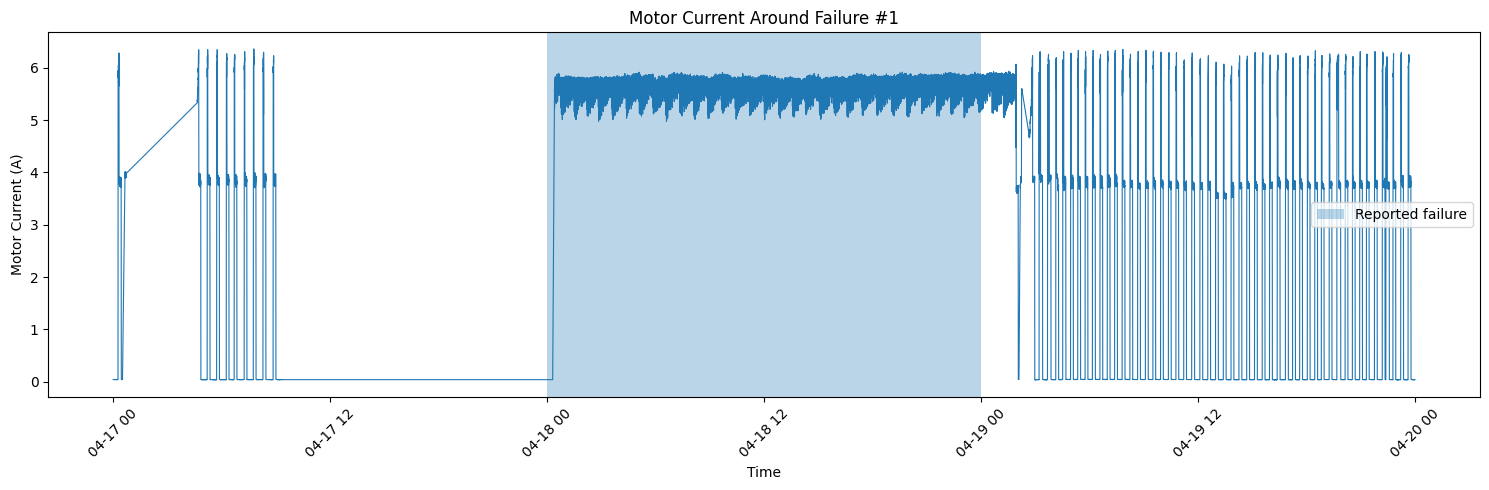

In [21]:
plt.figure(figsize=(15, 5))

plt.plot(
    event_df["timestamp"],
    event_df["Motor_current"],
    linewidth=0.8
)

plt.axvspan(
    pd.Timestamp(event["start"]),
    pd.Timestamp(event["end"]),
    alpha=0.3,
    label="Reported failure"
)

plt.title("Motor Current Around Failure #1")
plt.xlabel("Time")
plt.ylabel("Motor Current (A)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
for _, event in failure_df.iterrows():
    mask = (
        (df["timestamp"] >= event["start"]) &
        (df["timestamp"] <= event["end"])
    )
    
    print(
        f"Failure #{event['failure_id']}: "
        f"{mask.sum():,} observations"
    )

Failure #1: 8,657 observations
Failure #2: 2,360 observations
Failure #3: 17,315 observations
Failure #4: 1,622 observations


In [23]:
sensor_columns = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses"
]

comparison_results = []

for _, event in failure_df.iterrows():

    failure_start = event["start"]
    failure_end = event["end"]

    # 24 hours before failure
    before_start = failure_start - pd.Timedelta(hours=24)

    before_df = df[
        (df["timestamp"] >= before_start) &
        (df["timestamp"] < failure_start)
    ]

    failure_df_data = df[
        (df["timestamp"] >= failure_start) &
        (df["timestamp"] <= failure_end)
    ]

    for sensor in sensor_columns:

        before_mean = before_df[sensor].mean()
        failure_mean = failure_df_data[sensor].mean()

        comparison_results.append({
            "failure_id": event["failure_id"],
            "sensor": sensor,
            "before_mean": before_mean,
            "failure_mean": failure_mean,
            "change": failure_mean - before_mean
        })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,failure_id,sensor,before_mean,failure_mean,change
0,1,TP2,0.194092,8.518244,8.324152
1,1,TP3,8.468162,8.811901,0.343739
2,1,H1,8.247850,0.079266,-8.168584
3,1,DV_pressure,-0.022322,1.879373,1.901696
4,1,Reservoirs,8.468139,8.812990,0.344851
5,1,Oil_temperature,50.451532,74.131125,23.679594
6,1,Motor_current,0.451152,5.604374,5.153221
7,1,COMP,0.834947,0.008201,-0.826745
8,1,DV_eletric,0.023806,0.989488,0.965683
9,1,Towers,0.846850,0.501213,-0.345637


code below 
Why are we doing this?

This tells us which variables behaved differently during Failure #1 compared with the preceding 24 hours.

But don't conclude that a large change means the sensor is a good predictor yet. The variables have different units and scales, so later we'll normalize/standardize the changes properly.

In [24]:
failure_1_comparison = comparison_df[
    comparison_df["failure_id"] == 1
].copy()

failure_1_comparison

failure_1_comparison["abs_change"] = (
    failure_1_comparison["change"].abs()
)

failure_1_comparison.sort_values(
    "abs_change",
    ascending=False
)

,failure_id,sensor,before_mean,failure_mean,change,abs_change
5,1,Oil_temperature,50.451532,74.131125,23.679594,23.679594
0,1,TP2,0.194092,8.518244,8.324152,8.324152
2,1,H1,8.247850,0.079266,-8.168584,8.168584
6,1,Motor_current,0.451152,5.604374,5.153221,5.153221
3,1,DV_pressure,-0.022322,1.879373,1.901696,1.901696
8,1,DV_eletric,0.023806,0.989488,0.965683,0.965683
7,1,COMP,0.834947,0.008201,-0.826745,0.826745
10,1,MPG,0.834947,0.008201,-0.826745,0.826745
9,1,Towers,0.846850,0.501213,-0.345637,0.345637
4,1,Reservoirs,8.468139,8.812990,0.344851,0.344851


for all 4 failures repeating the process 


In [25]:
for failure_id in range(1, 5):

    print(f"\n========== FAILURE #{failure_id} ==========")

    temp = comparison_df[
        comparison_df["failure_id"] == failure_id
    ].copy()

    temp["abs_change"] = temp["change"].abs()

    print(
        temp.sort_values(
            "abs_change",
            ascending=False
        )[[
            "sensor",
            "before_mean",
            "failure_mean",
            "change"
        ]].head(10).to_string(index=False)
    )


========== FAILURE #1 ==========
         sensor  before_mean  failure_mean    change
Oil_temperature    50.451532     74.131125 23.679594
            TP2     0.194092      8.518244  8.324152
             H1     8.247850      0.079266 -8.168584
  Motor_current     0.451152      5.604374  5.153221
    DV_pressure    -0.022322      1.879373  1.901696
     DV_eletric     0.023806      0.989488  0.965683
           COMP     0.834947      0.008201 -0.826745
            MPG     0.834947      0.008201 -0.826745
         Towers     0.846850      0.501213 -0.345637
     Reservoirs     8.468139      8.812990  0.344851

========== FAILURE #2 ==========
         sensor  before_mean  failure_mean    change
Oil_temperature    66.250502     75.870837  9.620335
             H1     7.747303      0.071025 -7.676277
            TP2     1.239644      8.175207  6.935563
  Motor_current     2.130978      5.566485  3.435507
    DV_pressure     0.014037      1.924560  1.910523
            MPG     0.861104   

In [26]:
import pandas as pd

failure_periods = [
    {
        "failure_id": 1,
        "start": "2020-04-18 00:00:00",
        "end": "2020-04-18 23:59:00"
    },
    {
        "failure_id": 2,
        "start": "2020-05-29 23:30:00",
        "end": "2020-05-30 06:00:00"
    },
    {
        "failure_id": 3,
        "start": "2020-06-05 10:00:00",
        "end": "2020-06-07 14:30:00"
    },
    {
        "failure_id": 4,
        "start": "2020-07-15 14:30:00",
        "end": "2020-07-15 19:00:00"
    }
]

failure_df = pd.DataFrame(failure_periods)

failure_df["start"] = pd.to_datetime(failure_df["start"])
failure_df["end"] = pd.to_datetime(failure_df["end"])

failure_df

,failure_id,start,end
0,1,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,2020-07-15 14:30:00,2020-07-15 19:00:00


In [27]:
windows = [24, 12, 6, 3, 1]

important_sensors = [
    "TP2",
    "H1",
    "Oil_temperature",
    "Motor_current",
    "DV_pressure",
    "TP3",
    "Reservoirs"
]

pre_failure_results = []

for _, event in failure_df.iterrows():

    failure_start = event["start"]

    for hours in windows:

        window_start = failure_start - pd.Timedelta(hours=hours)

        window_data = df[
            (df["timestamp"] >= window_start) &
            (df["timestamp"] < failure_start)
        ]

        for sensor in important_sensors:

            pre_failure_results.append({
                "failure_id": event["failure_id"],
                "window_hours": hours,
                "sensor": sensor,
                "mean": window_data[sensor].mean(),
                "std": window_data[sensor].std(),
                "observations": len(window_data)
            })

pre_failure_df = pd.DataFrame(pre_failure_results)

print("Pre-failure analysis completed.")
print("Rows:", len(pre_failure_df))

pre_failure_df.head(10)

Pre-failure analysis completed.
Rows: 140


,failure_id,window_hours,sensor,mean,std,observations
0,1,24,TP2,0.194092,1.373245,6301
1,1,24,H1,8.247850,1.363467,6301
2,1,24,Oil_temperature,50.451532,3.347680,6301
3,1,24,Motor_current,0.451152,1.301972,6301
4,1,24,DV_pressure,-0.022322,0.081955,6301
5,1,24,TP3,8.468162,0.479627,6301
6,1,24,Reservoirs,8.468139,0.479377,6301
7,1,12,TP2,-0.018000,0.000000,3581
8,1,12,H1,8.238000,0.000000,3581
9,1,12,Oil_temperature,49.450000,0.000000,3581


In [28]:
pre_failure_df[
    (pre_failure_df["failure_id"] == 1)
].sort_values(
    ["sensor", "window_hours"],
    ascending=[True, False]
)

,failure_id,window_hours,sensor,mean,std,observations
4,1,24,DV_pressure,-0.022322,8.195492e-02,6301
11,1,12,DV_pressure,-0.024000,6.939863e-18,3581
18,1,6,DV_pressure,-0.024000,6.940833e-18,1790
25,1,3,DV_pressure,-0.024000,6.942774e-18,895
32,1,1,DV_pressure,-0.024000,3.475283e-18,298
1,1,24,H1,8.247850,1.363467e+00,6301
8,1,12,H1,8.238000,0.000000e+00,3581
15,1,6,H1,8.238000,0.000000e+00,1790
22,1,3,H1,8.238000,0.000000e+00,895
29,1,1,H1,8.238000,0.000000e+00,298


In [29]:
# Non-overlapping time bands before each failure

bands = [
    ("24-12h", 24, 12),
    ("12-6h", 12, 6),
    ("6-3h", 6, 3),
    ("3-1h", 3, 1),
    ("1h-0h", 1, 0)
]

important_sensors = [
    "TP2",
    "H1",
    "Oil_temperature",
    "Motor_current",
    "DV_pressure",
    "TP3",
    "Reservoirs"
]

band_results = []

for _, event in failure_df.iterrows():

    failure_start = event["start"]

    for band_name, start_hours, end_hours in bands:

        window_start = failure_start - pd.Timedelta(hours=start_hours)
        window_end = failure_start - pd.Timedelta(hours=end_hours)

        window_data = df[
            (df["timestamp"] >= window_start) &
            (df["timestamp"] < window_end)
        ]

        for sensor in important_sensors:

            band_results.append({
                "failure_id": event["failure_id"],
                "band": band_name,
                "sensor": sensor,
                "mean": window_data[sensor].mean(),
                "std": window_data[sensor].std(),
                "observations": len(window_data)
            })

band_df = pd.DataFrame(band_results)

band_df.head(10)

,failure_id,band,sensor,mean,std,observations
0,1,24-12h,TP2,0.473321,2.057235e+00,2720
1,1,24-12h,H1,8.260818,2.075370e+00,2720
2,1,24-12h,Oil_temperature,51.770092,4.786077e+00,2720
3,1,24-12h,Motor_current,0.992452,1.847137e+00,2720
4,1,24-12h,DV_pressure,-0.020114,1.247156e-01,2720
5,1,24-12h,TP3,8.758015,6.205886e-01,2720
6,1,24-12h,Reservoirs,8.757961,6.201660e-01,2720
7,1,12-6h,TP2,-0.018000,0.000000e+00,1791
8,1,12-6h,H1,8.238000,0.000000e+00,1791
9,1,12-6h,Oil_temperature,49.450000,7.107412e-15,1791


In [30]:
band_df[
    band_df["failure_id"] == 1
].sort_values(
    ["sensor", "band"]
)

,failure_id,band,sensor,mean,std,observations
11,1,12-6h,DV_pressure,-0.024000,6.940832e-18,1791
32,1,1h-0h,DV_pressure,-0.024000,3.475283e-18,298
4,1,24-12h,DV_pressure,-0.020114,1.247156e-01,2720
25,1,3-1h,DV_pressure,-0.024000,3.472356e-18,597
18,1,6-3h,DV_pressure,-0.024000,6.942774e-18,895
8,1,12-6h,H1,8.238000,0.000000e+00,1791
29,1,1h-0h,H1,8.238000,0.000000e+00,298
1,1,24-12h,H1,8.260818,2.075370e+00,2720
22,1,3-1h,H1,8.238000,0.000000e+00,597
15,1,6-3h,H1,8.238000,0.000000e+00,895


In [31]:
# Check actual time coverage in each pre-failure band

coverage_results = []

for _, event in failure_df.iterrows():

    failure_start = event["start"]

    for band_name, start_hours, end_hours in bands:

        window_start = failure_start - pd.Timedelta(hours=start_hours)
        window_end = failure_start - pd.Timedelta(hours=end_hours)

        window_data = df[
            (df["timestamp"] >= window_start) &
            (df["timestamp"] < window_end)
        ].copy()

        if len(window_data) > 0:
            actual_start = window_data["timestamp"].min()
            actual_end = window_data["timestamp"].max()
            actual_duration = actual_end - actual_start
        else:
            actual_start = pd.NaT
            actual_end = pd.NaT
            actual_duration = pd.Timedelta(0)

        expected_duration = window_end - window_start

        coverage_results.append({
            "failure_id": event["failure_id"],
            "band": band_name,
            "expected_duration": expected_duration,
            "actual_duration": actual_duration,
            "observations": len(window_data)
        })

coverage_df = pd.DataFrame(coverage_results)

coverage_df["coverage_percent"] = (
    coverage_df["actual_duration"] /
    coverage_df["expected_duration"] * 100
)

coverage_df

,failure_id,band,expected_duration,actual_duration,observations,coverage_percent
0,1,24-12h,0 days 12:00:00,0 days 11:59:46,2720,99.967593
1,1,12-6h,0 days 06:00:00,0 days 05:59:55,1791,99.976852
2,1,6-3h,0 days 03:00:00,0 days 02:59:42,895,99.833333
3,1,3-1h,0 days 02:00:00,0 days 01:59:50,597,99.861111
4,1,1h-0h,0 days 01:00:00,0 days 00:59:43,298,99.527778
5,2,24-12h,0 days 12:00:00,0 days 11:59:52,3108,99.981481
6,2,12-6h,0 days 06:00:00,0 days 05:59:50,2179,99.953704
7,2,6-3h,0 days 03:00:00,0 days 02:59:45,1089,99.861111
8,2,3-1h,0 days 02:00:00,0 days 01:59:56,727,99.944444
9,2,1h-0h,0 days 01:00:00,0 days 00:59:49,363,99.694444


In [32]:
# Compare mean sensor values across pre-failure bands
# for all four documented failures

band_mean_table = band_df.pivot_table(
    index=["failure_id", "band"],
    columns="sensor",
    values="mean"
)

band_mean_table


sensor             DV_pressure        H1  Motor_current  Oil_temperature  \
failure_id band                                                            
1          12-6h     -0.024000  8.238000       0.040000        49.450000   
           1h-0h     -0.024000  8.238000       0.040000        49.450000   
           24-12h    -0.020114  8.260818       0.992452        51.770092   
           3-1h      -0.024000  8.238000       0.040000        49.450000   
           6-3h      -0.024000  8.238000       0.040000        49.450000   
2          12-6h     -0.014495  7.849477       2.071308        67.263068   
           1h-0h      0.510424  6.044595       2.475468        64.675000   
           24-12h    -0.012153  7.740336       2.320466        66.922338   
           3-1h       0.010140  7.921730       1.682331        62.897146   
           6-3h      -0.016990  8.013868       1.894258        65.070845   
3          12-6h     -0.011787  8.115291       1.604317        62.093919   
           1h-0h      0.347807  6.616105       2.403430        65.338705   
           24-12h    -0.014437  8.047366       1.743227        64.507549   
           3-1h      -0.008946  7.953488       2.063012        64.811795   
           6-3h      -0.017017  7.866913       1.877013        63.448003   
4          12-6h     -0.003291  5.566958       4.519696        72.560560   
           1h-0h     -0.008727  2.580386       5.212741        78.978719   
           24-12h    -0.010016  6.517165       3.770818        70.222429   
           3-1h       0.002961  4.374452       4.767345        75.476446   
           6-3h       0.007648  5.337745       4.554193        73.681032   

sensor             Reservoirs       TP2       TP3  
failure_id band                                    
1          12-6h     8.248000 -0.018000  8.248000  
           1h-0h     8.248000 -0.018000  8.248000  
           24-12h    8.757961  0.473321  8.758015  
           3-1h      8.248000 -0.018000  8.248000  
           6-3h      8.248000 -0.018000  8.248000  
2          12-6h     9.050429  1.170354  9.049429  
           1h-0h     8.829598  2.641245  8.829554  
           24-12h    9.034185  1.273354  9.033838  
           3-1h      8.990072  1.043653  8.989769  
           6-3h      9.004961  0.945719  9.004615  
3          12-6h     9.007550  0.849643  9.008046  
           1h-0h     8.980887  2.254815  8.980419  
           24-12h    9.015041  0.927866  9.014508  
           3-1h      9.145078  1.121216  9.145477  
           6-3h      8.960887  1.017499  8.961436  
4          12-6h     9.091501  3.533239  9.090157  
           1h-0h     9.297124  6.798909  9.298187  
           24-12h    9.063450  2.517691  9.061982  
           3-1h      9.166884  4.817691  9.166008  
           6-3h      9.128483  3.781727  9.126868

In [33]:
# Calculate change from 24-12h to 1h-0h
# for each sensor and each failure

early = band_df[band_df["band"] == "24-12h"][
    ["failure_id", "sensor", "mean"]
].rename(columns={"mean": "early_mean"})

late = band_df[band_df["band"] == "1h-0h"][
    ["failure_id", "sensor", "mean"]
].rename(columns={"mean": "late_mean"})

sensor_changes = early.merge(
    late,
    on=["failure_id", "sensor"]
)

sensor_changes["absolute_change"] = (
    sensor_changes["late_mean"] -
    sensor_changes["early_mean"]
)

sensor_changes["percent_change"] = (
    sensor_changes["absolute_change"] /
    sensor_changes["early_mean"].abs()
) * 100

sensor_changes.sort_values(
    ["sensor", "failure_id"]
)

,failure_id,sensor,early_mean,late_mean,absolute_change,percent_change
4,1,DV_pressure,-0.020114,-0.024000,-0.003886,-19.320051
11,2,DV_pressure,-0.012153,0.510424,0.522577,4299.932610
18,3,DV_pressure,-0.014437,0.347807,0.362245,2509.077870
25,4,DV_pressure,-0.010016,-0.008727,0.001289,12.870265
1,1,H1,8.260818,8.238000,-0.022818,-0.276224
8,2,H1,7.740336,6.044595,-1.695741,-21.907846
15,3,H1,8.047366,6.616105,-1.431262,-17.785465
22,4,H1,6.517165,2.580386,-3.936780,-60.406318
3,1,Motor_current,0.992452,0.040000,-0.952452,-95.969579
10,2,Motor_current,2.320466,2.475468,0.155003,6.679805


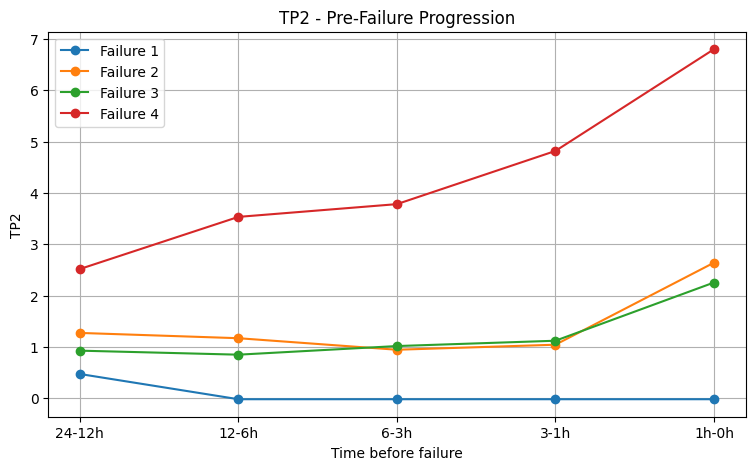

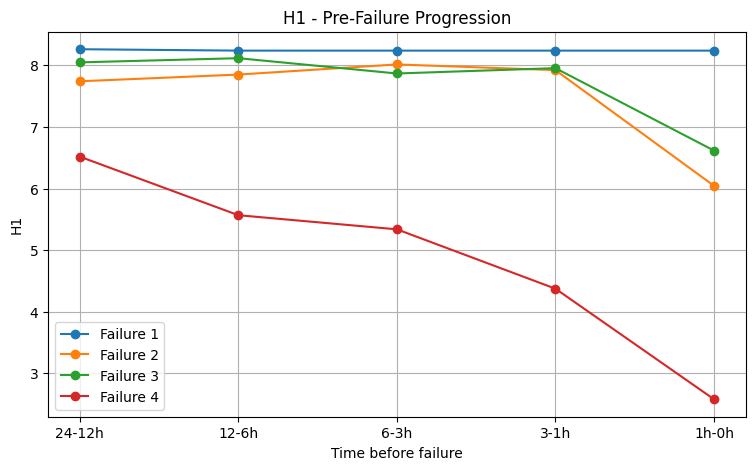

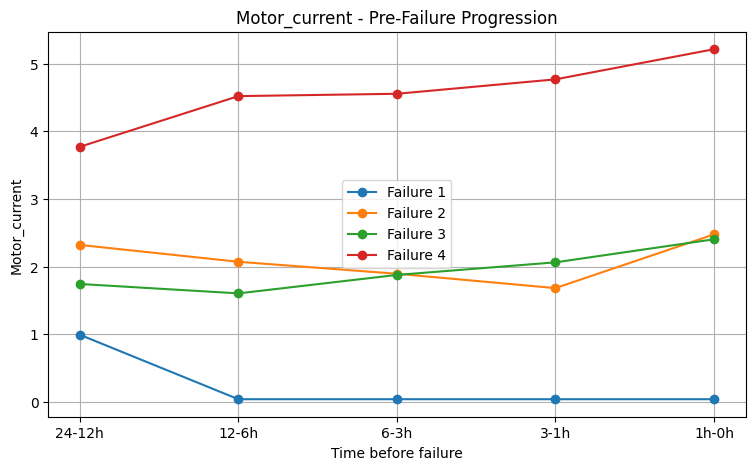

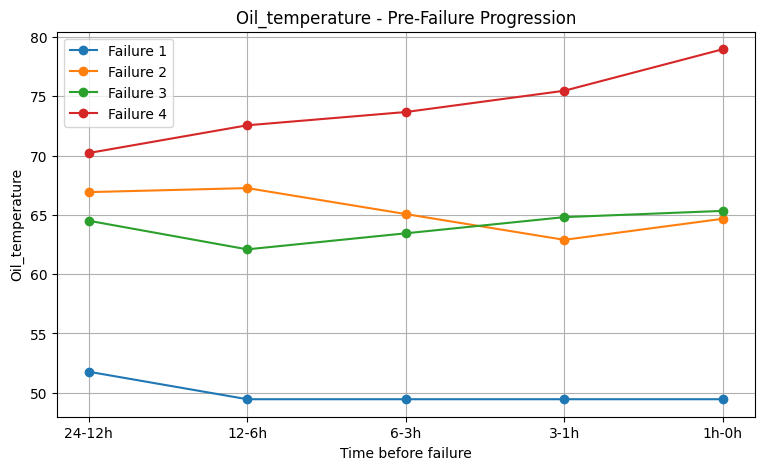

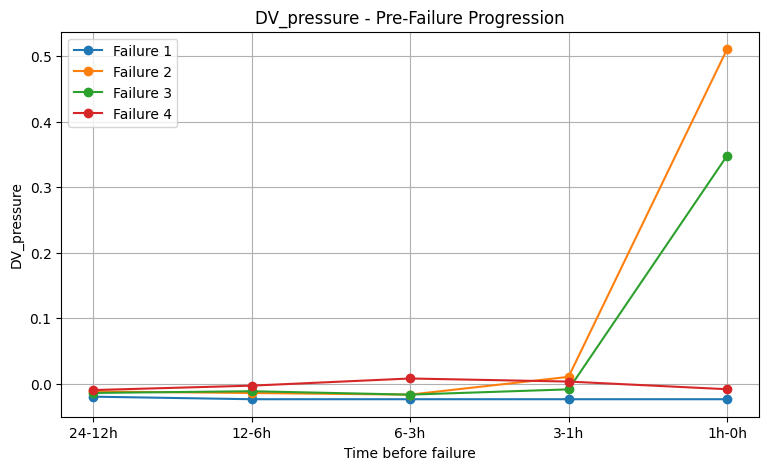

In [34]:
# Plot pre-failure progression for selected sensors across all failures

selected_sensors = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure"
]

band_order = ["24-12h", "12-6h", "6-3h", "3-1h", "1h-0h"]

plot_df = band_df[
    band_df["sensor"].isin(selected_sensors)
].copy()

plot_df["band"] = pd.Categorical(
    plot_df["band"],
    categories=band_order,
    ordered=True
)

for sensor in selected_sensors:

    sensor_data = plot_df[
        plot_df["sensor"] == sensor
    ]

    plt.figure(figsize=(9, 5))

    for failure_id in sorted(sensor_data["failure_id"].unique()):

        failure_data = sensor_data[
            sensor_data["failure_id"] == failure_id
        ].sort_values("band")

        plt.plot(
            failure_data["band"],
            failure_data["mean"],
            marker="o",
            label=f"Failure {failure_id}"
        )

    plt.title(f"{sensor} - Pre-Failure Progression")
    plt.xlabel("Time before failure")
    plt.ylabel(sensor)
    plt.legend()
    plt.grid(True)
    plt.show()
    

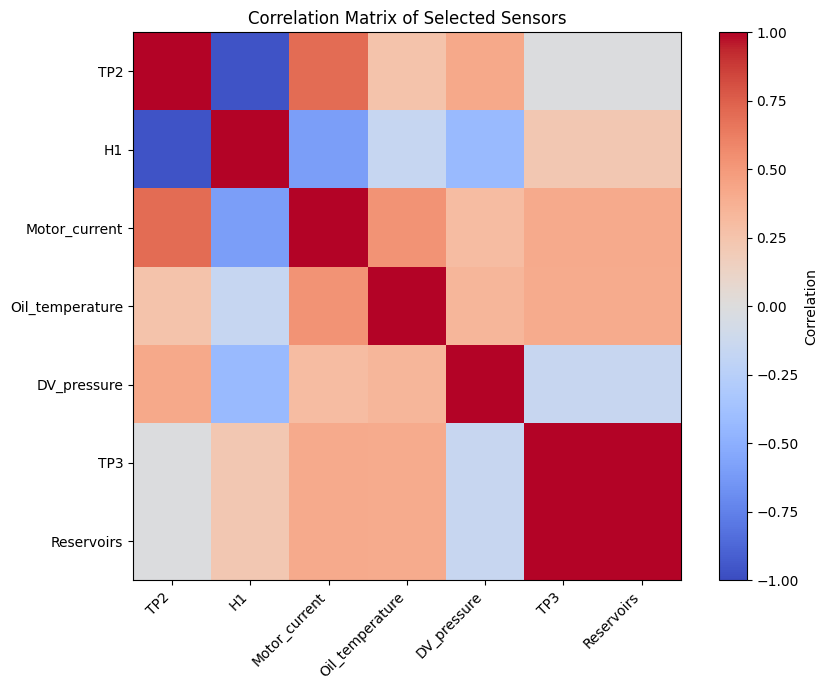

In [35]:
# Correlation matrix for selected variables

selected_sensors = [
    "TP2",
    "H1",
    "Motor_current",
    "Oil_temperature",
    "DV_pressure",
    "TP3",
    "Reservoirs"
]

selected_correlation = df[selected_sensors].corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    selected_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(selected_sensors)),
    selected_sensors,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(selected_sensors)),
    selected_sensors
)

plt.title("Correlation Matrix of Selected Sensors")

plt.tight_layout()
plt.show()